# ⚡ PhoBERT Fine-Tuning — Chuẩn Hóa Tin Đăng BDS
## 06 · Nguyễn Hữu Hiệu | FSB-NLP501 Final Project

**Nguồn dữ liệu:** `NLP.FSB Pool.xlsx` (chỉ dùng file này)  
**Kiến trúc:** `EncoderDecoderModel` — `vinai/phobert-base` × 2  
**Input:** Cột A — Mô tả thô (raw post)  
**Target:** Cột D — Mô tả chuẩn ĐẦY ĐỦ do chuyên gia viết (title `|` use_case + body)  
**Phân chia:** 9 train · 2 val · 9 test (từ hàng không có nhãn)  
**Môi trường:** Google Colab T4 GPU


In [1]:
!pip install transformers[torch] underthesea rouge-score bert-score \
             sentencepiece accelerate evaluate matplotlib -q
print('✅ Done')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 106.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.5 MB/s eta 0:00:00
✅ Done


In [2]:
import json, re, time, os, sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, EncoderDecoderModel,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    EarlyStoppingCallback, set_seed,
)
import evaluate as hf_evaluate
warnings.filterwarnings('ignore')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print(f'  {torch.cuda.get_device_name(0)} | {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device: cuda
  Tesla T4 | 15.6 GB


In [3]:
CFG = dict(
    model_name       = 'vinai/phobert-base',
    max_input_len    = 256,   # PhoBERT hard limit
    max_target_len   = 256,   # Column D content is long — use full budget
    batch_size       = 2,
    grad_accum       = 4,     # effective batch = 8
    epochs           = 50,
    lr               = 3e-5,
    warmup_ratio     = 0.15,
    weight_decay     = 0.01,
    num_beams        = 4,
    no_repeat_ngram  = 3,
    length_penalty   = 2.0,
    seed             = 42,
    output_dir       = './phobert_ckpt',
    pred_file        = 'HuuHieu_PhoBERT_predictions.json',
    perf_file        = 'HuuHieu_PhoBERT_performance.json',
)
set_seed(CFG['seed'])
os.makedirs(CFG['output_dir'], exist_ok=True)
print('Config OK')


Config OK


## 📦 Dataset từ `NLP.FSB Pool.xlsx`

| Split | Rows | Cột A | Cột D |
|:---|:---:|:---:|:---:|
| Train | 9 | ✅ raw post | ✅ human summary |
| Val | 2 | ✅ raw post | ✅ human summary |
| Test | 9 | ✅ raw post | ❌ không có nhãn |

**Cấu trúc cột D (target đầy đủ):**
```
{Title} | {Use case}

{CAPITALIZED HEADING}

– Vị trí: ...
– Hẻm: ...
– Kết cấu: ...
– Diện tích: ...
– Pháp lý: ...
– GIÁ: X tỷ (TL).
```
PhoBERT sẽ học sinh **toàn bộ cột D** từ cột A. Sau inference: tách title bằng ký tự `|`.


In [4]:
# ── Dữ liệu tải từ file json ─────────────────────────────────
import os
import json

if os.path.exists('train.json') and os.path.exists('val.json') and os.path.exists('test.json'):
    print('📂 Phát hiện train.json, val.json, test.json. Đang nạp dữ liệu từ file...')
    with open('train.json', 'r', encoding='utf-8') as f:
        TRAIN_RAW = json.load(f)
    with open('val.json', 'r', encoding='utf-8') as f:
        VAL_RAW = json.load(f)
    with open('test.json', 'r', encoding='utf-8') as f:
        TEST_RAW = json.load(f)
    
    # Map keys from unified format to expected format in this notebook
    for r in TRAIN_RAW:
        if 'raw_input_cleaned' in r: r['raw'] = r['raw_input_cleaned']
        if 'clean_description' in r: r['desc'] = r['clean_description']
    for r in VAL_RAW:
        if 'raw_input_cleaned' in r: r['raw'] = r['raw_input_cleaned']
        if 'clean_description' in r: r['desc'] = r['clean_description']
    for r in TEST_RAW:
        if 'raw_input_cleaned' in r: r['raw'] = r['raw_input_cleaned']
        if 'clean_description' in r: r['desc'] = r['clean_description']
        else: r['desc'] = ''
else:
    print('⚠️ Không tìm thấy file dữ liệu json. Đang sử dụng dữ liệu hardcoded mặc định...')
    # Fallback to hardcoded variables defined below

# ── Dữ liệu trực tiếp từ NLP.FSB Pool.xlsx ─────────────────────────────────
TRAIN_RAW = json.loads('[{"id": "SYS-20264727-938", "raw": "Nơ Trang Long 77.7/112.8 5 5.5 26 27.5 tỷ Bình Lợi Trung Bình Thạnh 25-50 tỷ HĐ Nguyễn Thị Anh Đào_ĐC Thiên Lam  H3GB nguồn Đối tác\\n*AĐ QUẬN BÌNH THẠNHNHÀ MẶT TIỀN NƠ TRANG LONG, PHAN VĂN TRỊ, QUẬN BÌNH THẠNH\xa0\xa0NHÀ\xa0\xa0SIÊU PHẨM ĐẸP, 3 TẦNG\xa0\xa05,5 X 20,5 CHỈ HƠN 27,5TỶ\xa0Nơ Trang Long\xa077.7/112,8 5 5,5 20,5 27,5 tỷ,phường , Quận Bình Thạnh, 15 đến 30. HĐ Đầu chủ Anh Đào Phòng Thiên Lam  Hoa hồng 3% giá bán Nguồn : Đối tác\xa0Mô tả:+ Kết cấu: Nhà trệt, gác, 4 phòng ngủ, 5\xa0\xa0wc, dòng tiền cho thuê 25 triệu /1 tháng, có thể thiết kế mở rộng thêm phòng, đầu tư thêm phòng cho thuê.+ BTCT: chuẩn, mot đời chủ, chủ tâm đắt xây dựng kiên cố và thiết kế thông thoáng\xa0+ Vị trí :+ Khu vực:\xa0giao nhau Qua, thông ra Nguyễn Văn Đậu, Phan Văn Trị, giao thông lưu hành nhanh qua các Quận trung Tâm. Gò Vấp, Quận 1, Quận 4, Quận 5+ Nhà gần Chợ Bà Chiểu, trường học, siêu thị , Bách hóa, Khu vui chơi giải trí....+ Chủ cần bán gấp trong tết\xa0+ Sổ hồng chính chủ, sổ tại gia. mua bán công chứng nhanh, chủ\xa0\xa0hỗ trợ vay Khách thiện chí.+ Anh chị em khảo sát, tìm ra điểm mạnhcủa\xa0\xa0căn nhà, dẫn khách chuẩn quy trình cty, báo trước ĐC ANH ĐÀO 60 phút, để được hỗ trợ tốt nhất.❤️\xa0🌹Chúc Anh Chị Em chốt nhà NHANH🌹", "desc": "Mặt tiền Nơ Trang Long Bình Thạnh - 77.7m2 (5.5x20.5) - Ngang khủng - 27.5 Tỷ | Kinh doanh hoặc CHDV\\n\\nMẶT TIỀN KINH DOANH NƠ TRANG LONG SÁT VÁCH PHAN VĂN TRỊ CHỈ 27.5 TỶ\\n\\n– Vị trí: Ngay Mặt tiền Nơ Trang Long, Phường 11, Quận Bình Thạnh. Vị trí đắc địa ngay nút giao thông trục Phan Văn Trị và Nguyễn Văn Đậu, kết nối trực tiếp sang trung tâm Quận 1 và Sân bay Tân Sơn Nhất chỉ vài phút di chuyển.\\n\\n– Mặt tiền: Đường nhựa rộng lớn, vỉa hè thông thoáng, dòng người qua lại nhộn nhịp ngày đêm, thích hợp mở văn phòng công ty, showroom, phòng khám hoặc kinh doanh đa ngành nghề.\\n\\n– Kết cấu: Nhà 3 tầng khung BTCT kiên cố, thiết kế thông thoáng, gồm 4 phòng ngủ, 5 WC. Hiện đang khai thác dòng tiền cho thuê ổn định 25 triệu/tháng.\\n\\n– Thông số xây dựng: Khu vực quy hoạch cao tầng. Thích hợp xây mới hầm, trệt, lửng, 4 lầu, sân thượng làm tòa nhà văn phòng hoặc căn hộ dịch vụ quy mô.\\n\\n– Diện tích: 112.8m2 (5.5m x 20.5m). Chiều ngang 5.5m bề thế cực kỳ hiếm có, khuôn đất vuông vức, phong thủy đẹp.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng chính chủ cất két, công chứng ngay trong ngày.\\n\\n– GIÁ: 27.5 tỷ (TL).\\n\\nPHÂN TÍCH TƯ DUY ĐẦU TƯ & DÒNG TIỀN:\\n\\n• Vị trí vàng trung tâm Bình Thạnh, liền kề các trục đường thương mại lớn và cụm Bệnh viện nhân dân Gia Định, Bệnh viện Ung Bướu, trường Đại học Văn Lang.\\n\\n• Khu vực tập trung tệp khách thuê cao cấp và nhân sự văn phòng cực kỳ đông đúc.\\n\\n• Khuôn đất lớn có chiều ngang vượt trội 5.5m là lợi thế tuyệt đối để tối ưu hóa không gian kinh doanh hoặc thiết kế CHDV hiệu suất cao.\\n\\n• Đầu tư xây mới thành tòa nhà văn phòng hoặc căn hộ dịch vụ cao cấp có thể mang lại nguồn thu nhập thụ động đạt trên 100 triệu/tháng.\\n\\n• Quỹ đất mặt tiền lõi trung tâm ngày càng khan hiếm, đảm bảo biên độ tăng giá ổn định và là tài sản giữ tiền có tính thanh khoản cực cao."}, {"id": "SYS-MP75438B-O8", "raw": "Lê Văn Sỹ 46 4 4.6 10 12.8 tỷ Nhiêu Lộc Quận 3 10-15 tỷ HĐ Trần Thanh Chương Đại Nam  H3GB nguồn Đầu chủ Trần Thanh Chương - Đại Nam\\n🚗🏡 HOT QUẬN 3- LÊ VĂN SỸ- NHỈNH 12 TỶ 🌹🌹🌹+ HĐĐT chính chủ, HKĐC.\\n\\n✅ Vị trí đẹp, trung tâm, con đường thời trang Lê Văn Sỹ.\\n\\n✅ Hẻm xe hơi đỗ cửa, gần Mặt tiền.\\n\\n✅ Nhà 1 trệt 3 lầu, 4 phòng ngủ, lô góc thoáng mát, ngang lớn là 1 lợi thế. Nhà mới vào là ở luôn.\\n\\n✅ Sổ đẹp, hoàn công đủ, pháp lý sạch.", "desc": "Hẻm xe hơi Lê Văn Sỹ Quận 3 - 46m2 (4.6x10) - Ngang lớn - 12.8 Tỷ | Ở ngay\\n\\nTRUNG TÂM QUẬN 3 ĐƯỜNG THỜI TRANG LÊ VĂN SỸ HẺM XE HƠI ĐỖ CỬA CHỈ 12.8 TỶ\\n\\n– Vị trí: Hẻm Lê Văn Sỹ, Phường 13, Quận 3. Vị trí trung tâm ngay lõi đường thời trang sầm uất, sát vách chợ Nguyễn Văn Trỗi, trường Đại học Sư phạm và bệnh viện An Sinh, di chuyển sang Quận 1 và Phú Nhuận chỉ trong vài phút.\\n\\n– Hẻm: Hẻm xe hơi đỗ cửa, sạch sẽ, an ninh, sát mặt tiền đường lớn, lưu thông thuận tiện và thông thoáng.\\n\\n– Kết cấu: Nhà 4 tầng, khung BTCT kiên cố. Thiết kế gồm 4 phòng ngủ, phòng khách, bếp, lô góc nhiều mặt thoáng đón ánh sáng tự nhiên. Nhà mới đẹp, dọn vào ở ngay.\\n\\n– Diện tích: 46m2 (4.6m x 10m), chiều ngang lớn 4.6m là lợi thế cực kỳ hiếm có tại phân khúc trung tâm Quận 3. Sổ vuông vức, hoàn công đầy đủ.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 12.8 tỷ (TL)."}, {"id": "SYS-MP756313-W", "raw": "Điện Biên Phủ 38.7 4 4.1 7 8.5 tỷ Phường 11 Quận 10 5-10 tỷ HĐ Nguyễn Văn Cường Bảo Tín  H3GB nguồn Đầu chủ Nguyễn Văn Cường - Bảo Tín\\n💥 HẺM Ô TÔ ĐỖ CỬA SÁT MẶT TIỀN ĐIỆN BIÊN PHỦ, P11, QUẬN 10 - 38.7M2 NGANG 4M - 4 TẦNG - CHỈ 8.5 TỶ\\n\\n\\nĐiện Biên Phủ 38.7 4 4/7.2 7.5 8.5 tỷ Phường 11 Quận 10, 5 đến 10, HĐ ĐC Nguyễn Cường,Khối Bảo Tín, Hoa Hồng 3% giá bán, nguồn ĐC Nguyễn Cường.\\n\\n\\n* Mô tả:\xa0\\n\\n\\n+ Diện tích: cn 38.7m2, ngang 4.06m dài 7.5m. Nở hậu đẹp: 7.2m\\n+ Kết cấu : gồm 4 tầng BTCT, có 3 phòng ngủ, 4 toilet, sân thượng,\\n+ Hẻm trước nhà 4m sạch sẽ, an ninh,dân trí...\\n+ Vị trí trung tâm quận 10, khu kinh doanh sầm uất, đủ tiện ích, thuận tiện đi lại.\\n+ Nhà chính chủ lâu năm, chưa qua đầu tư.\xa0\\n+ Pháp lí: Sổ hồng hoàn công\xa0\\n\\n\\n* Anh chị em dẫn khách ký phiếu YCCCDV đầy đủ và chuẩn quy trình, báo trước Đầu chủ 59 phút để được hỗ trợ tốt nhất.,\\n💥 Chúc anh chị em chốt bùng nổ", "desc": "Điện Biên Phủ Quận 10 - 39m2 (4.1x7.5) - Hẻm ô tô sát Mặt tiền - Ngang lớn - 8.5 Tỷ | Ở ngay\\n\\nHẺM Ô TÔ ĐỖ CỬA SÁT MẶT TIỀN ĐIỆN BIÊN PHỦ QUẬN 10 CHỈ 8.5 TỶ\\n\\n– Vị trí: Hẻm Điện Biên Phủ, Phường 11, Quận 10. Vị trí trung tâm sát vách Bệnh viện Bình Dân, Nhà hát Hòa Bình, di chuyển sang Quận 1 và Quận 3 chỉ 3 phút.\\n\\n– Hẻm: Hẻm ô tô rộng 4m sạch sẽ, dân trí cao, an ninh tuyệt đối, nhà cách mặt tiền đường lớn chỉ vài bước chân.\\n\\n– Kết cấu: Nhà 4 tầng, khung BTCT kiên cố, thiết kế hiện đại gồm 3 phòng ngủ, 4 WC, sân thượng thoáng mát. Nhà chính chủ lâu năm, dọn vào ở ngay.\\n\\n– Diện tích: 39m2 (4.1m x 7.5m), chiều ngang lớn 4.1m cực kỳ bề thế, phom nhà nở hậu tài lộc lên đến 7.2m.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.5 tỷ (TL)."}, {"id": "SYS-MP756P72-9B", "raw": "Cao Thắng 29.6/32 5 3.2 10 8.5 tỷ Bàn Cờ Quận 3 5-10 tỷ HĐ Lương Trần Tuyết Nhanh Tây Đô  H3GB nguồn Đầu chủ Lương Trần Tuyết Nhanh - Tây Đô\\nCHỦ NHIỆT BÁN GIẢM 200TR, GIÁ CÒN 8,5 TỶ\\n\\n\\nNHÀ 5 TẦNG - HẺM 5M - NGAY CHỢ - DÒNG TIỀN ỔN ĐỊNH THU NHẬP 300TR/ NĂM - CAO THẮNG P3 QUẬN 3 TPHCM\\n🌺🌺Giá chỉ nhỉnh 8 tỷ\\n\\n\\n- Diện tích: 32m( 3,2x10)\\n\\n\\n- Thiết kế: 1 trệt 1 lửng 2 lầu, sân thượng với 4pn 5wc\\n\\n\\n- Nhà ngay chợ tiện kinh doanh buôn bán\\n\\n\\n- Cách đường Nguyễn Thiện Thuật \xa050m\\n\\n\\n- Hẻm thông bàn cờ, xe hơi tới cửa\\n\\n\\n- Dòng tiền ổn định, Đang cho thuê thu nhập 300tr/ năm\\n\\n\\n- Sổ đẹp, hoàn công chuẩn\\n\\n\\n- Hỗ trợ khách vay\xa0\\n- Thứ ba 24/3 nhà trống ace thoải mái dẫn khách nhé\\n\\n\\n🌹Ace ks đi hẻm 51 Nguyễn Thiện Thuật vào 50m là tới\\n\\n\\nAce ks chụp selfie gửi hình lấy sổ, dẫn khách báo ĐC trước 60p. Chúc mn chốt nhà bùng nổ nhé🌹", "desc": "Cao Thắng Quận 3 - 32m2 - Hẻm xe hơi thông - 5 Tầng - 8.5 Tỷ | Ở ngay hoặc Dòng tiền\\n\\nTRUNG TÂM QUẬN 3 NÚT GIAO CAO THẮNG NGUYỄN THIỆN THUẬT HẺM XE HƠI THÔNG CHỈ 8.5 TỶ\\n\\n– Vị trí: Hẻm Cao Thắng, Phường 3, Quận 3. Vị trí lõi trung tâm sát vách chợ Bàn Cờ, tòa nhà văn phòng Thành Đô, di chuyển sang Quận 1 và Quận 10 chỉ 2 phút.\\n\\n– Hẻm: Hẻm rộng 5m thông bàn cờ ra đường Nguyễn Thiện Thuật, xe hơi tới cửa, di chuyển thông thoáng, sạch sẽ và an ninh.\\n\\n– Kết cấu: Nhà 5 tầng, khung BTCT kiên cố, thiết kế gồm 1 trệt, 1 lửng, 2 lầu, sân thượng với 4 phòng ngủ, 5 WC. Hiện trạng nhà đẹp, đang khai thác cho thuê dòng tiền ổn định 300 triệu/năm.\\n\\n– Diện tích: 32m2, sổ hồng vuông vức, hoàn công đầy đủ, không lỗi phong thủy.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.5 tỷ (TL)."}, {"id": "SYS-MP757WNV-DN", "raw": "Cách mạng tháng 8 44 2 3.7 12 7.5 tỷ Hòa Hưng Quận 10 5-10 tỷ HĐ Nguyễn Trần Ngọc Linh Tâm Đức  H3GB nguồn Đầu chủ Nguyễn Trần Ngọc Linh - Tâm Đức\\n🚗🏡 QUẬN 10 - XE HƠI TỚI NHÀ - 44M2 - HƠN 100M RA MẶT TIỀN 👉 CHỈ 7.5 TỶ\\n\\n\\n\\n\\n\\nCách Mạng Tháng Tám 44 2 3.7 12 7.5 tỷ Phường 13 Quận 10 6 đến 10 HĐ ĐC Ngọc Linh Phòng Tâm Đức , HH3%, nguồn ĐC Ngọc Linh.\\n\\n\\n\\n\\n💥 Mô tả:\xa0\\n\\n+ Vị trí đẹp, gần Tô Hiến Thành - Hoà Hưng, thuận tiện qua Quận 1, 3.\\n\\n+ Hiện trạng: 1 trệt 1 lầu, 3 PN, 2 vệ sinh.\xa0\\n\\n+ Xe hơi tới nhà, sát mặt tiền, khu vực kinh doanh sầm uất.\xa0\\n\\n+ Chủ gấp bán đi định cư.\xa0\\n\\n\\n\\n\\n+ Anh em dẫn khách vui lòng báo ĐC Ngọc Linh trước 30 phút để được hỗ trợ tốt.\\n\\n\\n\\n\\n+ Chúc anh em chốt nhà bùng nổ.🌹🌹Facebook: Nguyễn Linh", "desc": "Cách Mạng Tháng Tám Quận 10 - 44m2 (3.7x12) - Hẻm xe hơi tới nhà - 7.5 Tỷ | Ở ngay\\n\\nTRUNG TÂM QUẬN 10 LIỀN KỀ CÔNG VIÊN LÊ THỊ RIÊNG HẺM XE HƠI TỚI CỬA CHỈ 7.5 TỶ\\n\\n– Vị trí: Hẻm Cách Mạng Tháng Tám, Phường 13, Quận 10. Vị trí vàng ngay trung tâm, sát vách CLB Lan Anh, trường Đại học Huflit, di chuyển sang Quận 1 và Quận 3 chỉ 3 phút.\\n\\n– Hẻm: Hẻm xe hơi rộng rãi, thông thoáng, xe hơi đỗ tận cửa nhà, cách mặt tiền đường lớn Cách Mạng Tháng Tám chỉ hơn 100m, khu vực dân trí cao và an ninh tuyệt đối.\\n\\n– Kết cấu: Nhà 2 tầng, khung BTCT kiên cố, công năng tối ưu gồm 3 phòng ngủ, 2 WC. Hiện trạng nhà sạch sẽ, không gian thoáng đãng, khách mua dọn vào ở ngay.\\n\\n– Diện tích: 44m2 (3.7m x 12m), khuôn đất vuông vức từ đầu đến đuôi, không bị lỗi phong thủy hay lộ giới.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 7.5 tỷ (TL)."}, {"id": "SYS-MP758TA8-AN", "raw": "Lê Văn Sỹ 32.5 4 2.8 10 8.3 tỷ Phường 13 Quận 3 5-10 tỷ HĐ Phạm Thanh Hải Tâm Đức  H3GB nguồn Đầu chủ Phạm Thanh Hải - Tâm Đức\\nHIẾM -HẺM XE HƠI ĐỖ CỬA LÊ VĂN SỸ Q3 - NHÀ ĐẸP - TRỆT, 3 LẦU, SÂN THƯỢNG - NỞ HẬU TÀI LỘC - CHỈ NHỈNH 8 TỶ\\n\\n\\n\\n\\nLê Văn Sỹ 32.5 4 2.75/4.25 10 8.3 Tỷ Phường 13 Quận 3 5 đến 10 HĐ Đầu chủ Hải - Phòng Tâm Đức , H3%, nguồn Đầu chủ Hải.\\n\\n*hdcc - ký với chị gái chủ\\n\\n\\n\\n\\n\xa0Mô tả:\xa0\\n\\n+ Trung tâm kinh đô thời trang Lê Văn Sỹ, Quận 3 - Phường Nhiêu Lộc Mới.\xa0\\n\\n+ Kết cấu: 4 tầng BTCT - Trệt, 3 lầu, sân thượng hoàn công đủ.\\n\\nGồm: khách, bếp, 3 PN, 4 vệ sinh, ban công, sân thượng lớn.\xa0\\n\\n+ Hẻm xe hơi đỗ cửa, thông Trần Quang Diệu\\n\\n+ Hàng xóm đồng bộ cao tầng, dân trí cao.\xa0\\n\\n+ Sổ sạch, pháp lý chuẩn chỉnh, hoàn công đủ, công chứng mua bán ngay.\\n\\n\\n\\n\\n🌹\xa0Anh chị em khảo sát inbox gửi ảnh tự sướng tới Đầu chủ để nhận sổ tư vấn khách, dẫn khách ký phiếu YCCCDV đầy đủ và chuẩn quy trình báo trước Đầu chủ Hải 60 phút để VIẾT CỌC nhé ạ.\\n\\nFacebook: Phạm Thanh Hải\xa0\\n\\nPhòng Tâm Đức\\n\\n\\n\\n\\n🌹🌽", "desc": "Lê Văn Sỹ Quận 3 - 33m2 (4.3x10) - Hẻm xe hơi thông - Ngang lớn - 8.3 Tỷ | Ở ngay\\n\\nKINH ĐÔ THỜI TRANG LÊ VĂN SỸ TRUNG TÂM QUẬN 3 HẺM XE HƠI THÔNG CHỈ 8.3 TỶ\\n\\n– Vị trí: Hẻm Lê Văn Sỹ, Phường 13, Quận 3. Vị trí lõi trung tâm sát vách trường Đại học Sư phạm và bệnh viện An Sinh, di chuyển sang Quận 1 và Phú Nhuận chỉ trong vài phút.\\n\\n– Hẻm: Hẻm xe hơi thông thoáng sang đường Trần Quang Diệu, xe hơi đỗ tận cửa, khu đồng bộ cao tầng, dân trí cao, không gian sạch sẽ và an ninh tuyệt đối.\\n\\n– Kết cấu: Nhà 4 tầng, khung BTCT kiên cố hoàn công đủ. Thiết kế hiện đại gồm phòng khách, bếp, 3 phòng ngủ lớn, 4 WC, ban công và sân thượng rộng thoáng. Nhà mới đẹp, khách dọn vào ở ngay.\\n\\n– Diện tích: 32.5m2 (4.25m x 10m), chiều ngang lớn 4.25m bề thế, thế đất nở hậu tài lộc cực kỳ đắc địa.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.3 tỷ (TL)."}, {"id": "SYS-MP759ESN-94", "raw": "Lê Văn Sỹ 35/40 3 3.1 13 8 tỷ Nhiêu Lộc Quận 3 5-10 tỷ HĐ Nguyễn Triệu Đức Trung Thiên Địa  H3GB nguồn Đầu chủ Nguyễn Triệu Đức Trung - Thiên Địa\\n🌷HẺM NHỰA XE TẢI SẠCH ĐẸP, 2 MẶT HẺM TRƯỚC SAU, CÓ CỬA SAU - KHU VIP DÂN TRÍ - ĐANG CHO THUÊ, PHÙ HỢP VỪA Ở VỪA KINH DOANH - 3 TẦNG LUNG LINH, VUÔNG ĐÉT, HOÀN CÔNG, CC NGAY🌷\\n\\n\\n🔎Định vị:\\nLưu ý: Nhà cho thuê, ACE dẫn khách xem clip và vị trí ạ.\\n🧭Hướng Bắc.\\n💥 Khu vip Q3 dân trí cao, hẻm nhựa xe tải sạch đẹp thông tứ tung, hẻm sau nhà 5m, phù hợp làm văn phòng/kinh doanh, đang cho người quen thuê giữ nhà 12tr/tháng.\\n🔥Kết cấu: 1 trệt 1 lửng 1 lầu, 4pn, 3wc, cửa sổ, ban công trước và sau nhà, có cửa ra vào sau nhà.\\n🔥Sổ vuông vức, hoàn công, pháp lý chuẩn, công chứng ngay.\\n\\n\\nFacebook: Triệu Trung.", "desc": "Hẻm xe tải Lê Văn Sỹ Quận 3 - 40m2 - 2 Mặt hẻm thông - 3 Tầng - 8 Tỷ | Ở ngay hoặc Văn phòng\\n\\nKHU VIP DÂN TRÍ LÊ VĂN SỸ QUẬN 3 HẺM NHỰA XE TẢI THÔNG TỨ TUNG CHỈ 8 TỶ\\n\\n– Vị trí: Hẻm Lê Văn Sỹ, Phường 13, Quận 3. Vị trí đắc địa ngay lõi trung tâm, sát vách Trường Đại học Sư phạm và Bệnh viện An Sinh, di chuyển sang Quận 1 và Phú Nhuận chỉ 3 phút.\\n\\n– Hẻm: Hẻm nhựa xe tải rộng thoáng, thông tứ tung, đặc biệt nhà sở hữu 2 mặt hẻm trước sau cực kỳ thông thoáng, hẻm sau rộng 5m có cửa hậu ra vào riêng biệt, phù hợp vừa ở vừa làm văn phòng công ty.\\n\\n– Kết cấu: Nhà 3 tầng, khung BTCT kiên cố gồm 1 trệt, 1 lửng, 1 lầu. Thiết kế tối ưu công năng với 4 phòng ngủ, 3 WC, hệ thống cửa sổ và ban công trước sau đón ánh sáng tự nhiên, hiện đang cho thuê ổn định 12 triệu/tháng.\\n\\n– Diện tích: 40m2, thế đất vuông đét, phong thủy đẹp, không lỗi lộ giới.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8 tỷ (TL)."}, {"id": "SYS-MP759ZIK-MM", "raw": "Nguyễn Thiện Thuật 30.7 2 3.1 11 8.2 tỷ Bàn Cờ Quận 3 5-10 tỷ HĐ Nguyễn Thị Kim Thoa_ĐC Linh Phát  H3GB nguồn Đầu chủ Nguyễn Thị Kim Thoa_ĐC - Linh Phát\\nVỊ TRÍ ĐẸP - KINH DOANH - HXT THÔNG TỨ TUNG\\n+ Kết cấu: 1 trệt, 1 lầu. ,\\n+ Nhà cũ. Sửa lại ở với 2PN 1WC. ,\\n+ HXT thông tứ tung, vị trí kinh doanh. ,\\n+ Vị trí an ninh sạch sẽ. Dân trí cao. ,\\n+ Sổ hồng chính chủ. công chứng ngay. ,", "desc": "Nguyễn Thiện Thuật Quận 3 - 31m2 - Hẻm xe tải thông kinh doanh - 8.2 Tỷ | Ở ngay hoặc Kinh doanh\\n\\nKHU VỰC KINH DOANH SẦM UẤT NGUYỄN THIỆN THUẬT QUẬN 3 HẺM XE TẢI THÔNG TỨ TUNG CHỈ 8.2 TỶ\\n\\n– Vị trí: Hẻm Nguyễn Thiện Thuật, Phường 3, Quận 3. Vị trí lõi trung tâm sát vách chợ Bàn Cờ và bệnh viện Bình Dân, di chuyển qua Quận 1 và Quận 10 chỉ trong vài bước chân.\\n\\n– Hẻm: Hẻm xe tải thông tứ tung, mặt hẻm sạch sẽ, dân trí cao, vị trí đắc địa phù hợp mở văn phòng đại diện, spa hoặc kinh doanh online dòng tiền tốt.\\n\\n– Kết cấu: Nhà cũ 2 tầng, khung BTCT kiên cố gồm 1 trệt 1 lầu. Công năng cơ bản 2 phòng ngủ, 1 WC, khách mua chỉ cần sơn sửa nhẹ là ở ngay hoặc khai thác kinh doanh được liền.\\n\\n– Diện tích: 31m2, khuôn đất vuông vức vuông đét, không lỗi phong thủy, phong thủy tốt.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.2 tỷ (TL)."}, {"id": "SYS-MP75AKU9-9R", "raw": "Cách Mạng Tháng 8 57.6/65 2 4.3 15 8 tỷ Nhiêu Lộc Quận 3 5-10 tỷ HĐ Vũ Hoàng Giang Thiên Ngọc  H3GB nguồn Hội đồng thẩm định\\n✅ Chủ điều chỉnh lại giá bán lên 8ty\\n\\n\\n\\n🔥🔥🔥7.3TỶ CHỐT TRƯỚC NGÀY 10/3 - \xa0THU 💵💵💵 THÔI ACE\\n\\n\\n💥💥💥GIẢM CHÀO MẠNH ĐỂ BÁN NHANH - ANH EM CHÀO KHÁCH TRỰC TIẾP GIÁ 7.5TỶ\\n\\n\\nCách Mạng Tháng 8 57.6/65 4.28 12.19/15 7.7tỷ Phường Nhiêu Lộc TPHCM (Phường 9 cũ), 6 đến 10 HĐ ĐC Vũ Giang, Phòng Thiên Ngọc , H3%, nguồn ĐC Vũ Giang.\\n\\n\\n✅BÁN NHÀ HẺM 210 CÁCH MẠNG THÁNG TÁM – QUẬN 3, XE HƠI ĐẦU CÁCH NHÀ HƠN 10m\\n\\n\\n➡️Vị trí: Hẻm 210 Cách Mạng Tháng Tám, phường Nhiêu Lộc, Quận 3 gần ngay Ga Đường Sắt Sài Gòn\\n\\n\\n✅Diện tích: 65m² (ngang 4.3m x dài 15m) đất vuông vức\\n\\n\\n✅Kết cấu hiện trạng: 1 trệt – 1 lầu, 3 phòng ngủ\\nPhòng khách & bếp rộng rãi, thoáng mát, có khoảng sân trước sau. Nhà ở tốt, sử dụng ngay\\n✳️Khu vực được phép xây cao đến 6 tầng. Phù hợp để ở hoặc xây căn hộ dịch vụ\\n\\n\\n❇️Tiện ích xung quanh:\\n- Gần chợ, trường học, khu dân cư hiện hữu, Ga Sài Gòn\\n- Trung tâm Quận 3, di chuyển thuận tiện các quận trung tâm\\n\\n\\n💰 Giá bán: 8 tỷ\\n(Ngân hàng hỗ trợ vay lên đến gần 7 tỷ)\\n\\n\\n☎️Giang Sang: \\n* Anh chị em dẫn khách đúng quy trình và báo trước ĐC Giang Sang 45Phut. Xin Cám ơn!,", "desc": "Cách Mạng Tháng Tám Quận 3 - 65m2 (4.3x15) - Sát hẻm xe hơi - Ngang lớn - 8 Tỷ | Ở ngay hoặc CHDV\\n\\nTRUNG TÂM QUẬN 3 LIỀN KỀ GA SÀI GÒN KHU VỰC XÂY CAO TẦNG CHỈ 8 TỶ\\n\\n– Vị trí: Hẻm Cách Mạng Tháng Tám, Phường 9, Quận 3. Vị trí lõi trung tâm sát vách CLB Lan Anh, kết nối thẳng ra Vòng xoay Dân Chủ, di chuyển qua Quận 1 và Quận 10 chỉ 2 phút.\\n\\n– Hẻm: Hẻm thông thoáng, sạch sẽ, khu dân trí cao và an ninh tuyệt đối, nhà cách hẻm xe hơi đỗ chỉ hơn 10m.\\n\\n– Kết cấu: Nhà 2 tầng, khung BTCT kiên cố gồm 1 trệt 1 lầu. Thiết kế bố trí 3 phòng ngủ, phòng khách, bếp rộng rãi, có khoảng sân trước sau lấy gió trời thông thoáng, nhà ở tốt sử dụng ngay.\\n\\n– Thông số xây dựng: Khu vực được phép xây cao tầng: Hầm, trệt, lửng, 4 lầu, sân thượng. Cực kỳ lý tưởng cho khách mua xây mới làm toà nhà văn phòng hoặc căn hộ dịch vụ cao cấp.\\n\\n– Diện tích: 65m2 (4.3m x 15m), chiều ngang lớn 4.3m bề thế, thế đất vuông vức phong thủy đẹp.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8 tỷ (TL).\\n\\nPHÂN TÍCH TƯ DUY ĐẦU TƯ & DÒNG TIỀN:\\n• Vị trí đắc địa lõi trung tâm Quận 3, sát vách dự án Tuyến Metro số 2 sắp triển khai, mang lại tiềm năng tăng trưởng đột biến và biên độ lãi kép cực cao.\\n• Khuôn đất lớn 65m2 với chiều ngang 4.3m lý tưởng, giấy phép xây dựng cho phép cao tầng (lên đến 6 tầng) giúp tối ưu hóa diện tích sàn khai thác kinh doanh.\\n• Tọa lạc tại khu vực tập trung lượng lớn giới văn phòng, người nước ngoài và liền kề các trục đường lớn, rất phù hợp để xây dựng mô hình CHDV cao cấp, dòng tiền khai thác dự kiến đạt từ 50 - 60 triệu/tháng."}]')
VAL_RAW   = json.loads('[{"id": "SYS-MP75ES0J-9K", "raw": "Huỳnh Văn Bánh 38 5 4.8 8 8.95 tỷ Phú Nhuận Phú Nhuận 5-10 tỷ HĐ Đặng Đình Trung Hiếu_ĐC Hắc Long  H3GB nguồn Đầu chủ Đặng Đình Trung Hiếu_ĐC - Hắc Long\\nGiảm 250tr còn 8.95 tỷ\\n\\n\\n\\n\\nKý hợp đồng điện tử\\n\\n\\n\\n\\n🌺5 TẦNG - 38M2 - AN NINH - HẺM XE HƠI- HƠN 8 TỶ💎\\n\\n\\n\\n\\n\\n\\n\\n🍀Mô tả:\\n\\n_ Kết cấu : Trệt 4 lầu hoàn công đủ.\\n\\n_ Gồm: 4 phòng ngủ, 5 tolet, phòng khách, bếp.\xa0\\n\\n_ Hẻm xe hơi đỗ cửa, cách mặt tiền đường 100m.\\n\\n_ Vị trí: Gần chợ, Trường học các cấp, thuận lợi di chuyển trung tâm Sài Gòn.\\n\\n_ Sổ hồng riêng, công chứng trong ngày.\\n\\n\\n\\n\\n💡LƯU Ý : ,,\\n\\n💥💥💥 Anh chị em ký phiếu YCDV dẫn khách theo quy trình công ty. Đầu chủ Đặng Hiếu đã soạn sẵn HĐ Đặt cọc, chỉ chờ anh em Thiên Khôi đến ký.✍️✍️✍️,,🌹🌹🌹🌹💥💥💥🌹🌹🌹🌹", "desc": "Huỳnh Văn Bánh Phú Nhuận - 38m2 (4.8x8) - Hẻm xe hơi đỗ cửa - Ngang lớn - 8.95 Tỷ | Ở ngay\\n\\nTRUNG TÂM PHÚ NHUẬN LIỀN KỀ TRỤC NGUYỄN VĂN TRỖI HẺM XE HƠI ĐỖ CỬA CHỈ 8.95 TỶ\\n\\n– Vị trí: Hẻm Huỳnh Văn Bánh, Phường 13, Quận Phú Nhuận. Vị trí vàng sát vách trục ngoại giao Nguyễn Văn Trỗi, di chuyển sang Quận 1 và Sân bay Tân Sơn Nhất chỉ 5 phút.\\n\\n– Hẻm: Hẻm xe hơi rộng rãi, đỗ tận cửa nhà, cách mặt tiền đường lớn Huỳnh Văn Bánh 100m, khu vực dân trí cao, yên tĩnh và an ninh tuyệt đối.\\n\\n– Kết cấu: Nhà 5 tầng, khung BTCT kiên cố hoàn công đủ, công năng gồm phòng khách, bếp, 4 phòng ngủ, 5 WC. Nhà mới đẹp, kiến trúc hiện đại, dọn vào ở ngay.\\n\\n– Diện tích: 38m2 (4.8m x 8m), chiều ngang lớn 4.8m bề thế, phom nhà vuông vức cân đối, bố trí không gian cực thoáng.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.95 tỷ (TL)."}, {"id": "SYS-MP75GT4Y-GN", "raw": "HUỲNH VĂN BÁNH 27.5/30 5 3.7 8 8.9 tỷ Phú Nhuận Phú Nhuận 5-10 tỷ HĐ Nguyễn Thị Thu Diễm Phát Lộc  H3GB nguồn Đầu chủ Nguyễn Thị Thu Diễm - Phát Lộc\\n🏡 SIÊU PHẨM NHÀ MỚI HẺM XE HƠI NGAY LÊ VĂN SỸ - 5 TẦNG SÂN THƯỢNG BTCT - 3PN 4WC FULL NỘI THẤT - CHỈ 8.9 TỶ\\n\\n\\n\\n\\nMô tả:\\n\\n+ Vị trí: HẺM VIP Huỳnh Văn Bánh, P.13, Phú Nhuận . Ngay Lê Văn Sỹ đoạn đường sầm uất, đầy đủ tiện ích.\\n\\n+ Diện tích : 3.7m ❌ 8m ( dtsd 110m2)\\n\\n+ Kết cấu: Trệt, lửng , 3 lầu, sân thượng BTCT. Gồm 3PN, 4WC, PK, bếp, phòng làm việc, sân thượng. Nhà lô góc nên rất thoáng và mát mẻ.\xa0\\n\\n+ Tặng Full nội thất : Sofa, máy lạnh, bộ bàn ăn, bếp, giường , tủ lạnh ...\\n\\n\\n\\n\\nLink Facebook:\xa0\\n\\n+ Anh chị em dẫn khách báo trước ĐC Diễm 45 phút để được hỗ trợ tốt nhất\\n\\n+ Chúc Anh Chị Em Thiên Khôi bùng nổ giao dịch", "desc": "Huỳnh Văn Bánh Phú Nhuận - 30m2 (3.7x8) - Hẻm xe hơi VIP - 8.9 Tỷ | Full nội thất xịn\\n\\nKHU VIP PHÚ NHUẬN ĐƯỜNG LÊ VĂN SỸ HẺM XE HƠI LÔ GÓC CHỈ 8.9 TỶ\\n\\n– Vị trí: Hẻm Huỳnh Văn Bánh, Phường 13, Quận Phú Nhuận. Vị trí vàng ngay đoạn giao trục Lê Văn Sỹ sầm uất, di chuyển sang Quận 1, Quận 3 và Sân bay Tân Sơn Nhất chỉ 5 phút.\\n\\n– Hẻm: Hẻm xe hơi rộng rãi, sạch sẽ, dân trí cao, xe hơi lưu thông thuận tiện, sát mặt tiền đường lớn.\\n\\n– Kết cấu: Nhà lô góc 5 tầng BTCT kiên cố. Thiết kế hiện đại gồm phòng khách, bếp, phòng làm việc, 3 phòng ngủ, 4 WC, sân thượng thoáng mát, tặng Full nội thất xịn vào ở ngay.\\n\\n– Diện tích: 30m2 (3.7m x 8m), khuôn đất vuông vức, kết cấu cao tầng tối ưu không gian sử dụng.\\n\\n– Pháp lý sạch, hoàn công đủ, sổ hồng riêng cất két, công chứng ngay.\\n\\n– GIÁ: 8.9 tỷ (TL)."}]')
TEST_RAW  = json.loads('[{"id": "SYS-MP75Z7G0-H3", "raw": "Cao Thắng 44.7/50 5 4.5 11 11.9 tỷ Hòa Hưng Quận 10 10-15 tỷ HĐ Nguyễn Duy Bảo Thiên Địa  H3GB nguồn Đầu chủ Nguyễn Duy Bảo - Thiên Địa\\n✨ 4/5/2026 Chủ đã đồng ý giảm 600tr 👉 Giá mới 11.9 Tỷ. Chốt 🤝\\n\\n👉 Chú ý: ACE đi khảo sát vui lòng chụp 1 ảnh selfie 🤳 gửi ĐC để nhận sổ nhé. Chốt 🤝\\n\\nNHÀ ĐẸP TRUNG TÂM QUẬN 10 – HẺM XE HƠI CAO THẮNG – KHU DÂN TRÍ CAO - AN NINH ĐỈNH\\n\\nMột căn nhà hiếm ở trung tâm Cao Thắng – Quận 10, nơi vừa đủ yên tĩnh để ở nhưng chỉ vài phút là chạm đến nhịp sống sôi động của trung tâm thành phố.\\n\\nThông tin chi tiết:\\n\\nĐịa chỉ: Cao Thắng, Phường 12, Quận 10\\n\\n📍Vị trí: Tọa lạc tại khu Cao Thắng – Ba Tháng Hai – Nguyễn Tri Phương, khu vực trung tâm Quận 10 với đầy đủ tiện ích:\\n\\nTrường học – bệnh viện – trung tâm thương mại – nhà hàng – quán cà phê – tất cả trong bán kính vài phút di chuyển.\\n\\n• Diện tích đất: 44.7m²\\n\\n• Diện tích sàn: 186.4m²\\n\\n• Kết cấu: 1 trệt + lửng + 3 lầu (5 tầng)\\n\\n• Nhà xây kiên cố, sàn BTCT – mái BTCT, móng đóng cọc, chính chủ xây dựng tâm huyết trong 6 tháng.\\n\\n+ Trệt: Phòng khách rộng, trần cao thoáng đãng, có 1 PN phía sau, 1 WC.\\n\\n+ Lửng: Bếp và phòng ăn thiết kế gọn gàng, tiện nghi.\\n\\n+ Lầu 1 - 2: mỗi tầng 2 phòng ngủ thoáng sáng, có ban công, cửa sổ, 2 WC khép kín.\\n\\n👉 Tổng: 5 PN 5 WC\\n\\n• Pháp lý: Sổ hồng riêng – đất ở đô thị – sở hữu lâu dài\\n\\n• Nhà được chăm chút kỹ lưỡng, có thể vào ở ngay\\n\\n✨ Phù hợp:\\n\\n• Gia đình ở lâu dài\\n\\n• Mua giữ tài sản trung tâm\\n\\n• Kết hợp ở và làm văn phòng\\n\\n💰 Giá bán: 12.5 tỷ (TL)\\n\\n---\\n\\nACE khảo sát dẫn khách theo qui trình Cty. Alô PP Bảo 24/7 để được hỗ trợ kịp thời. Chúc ACE hái🌹rực rỡ.\\n\\nBBK\\n\\nChuẩn mực từng giao dịch", "desc": ""}, {"id": "SYS-MP75ZR8R-C4", "raw": "Cao Thắng 39 4 5.3 8 14.58 tỷ Hòa Hưng Quận 10 10-15 tỷ HĐ Phạm Văn Hà (Đầu chủ) Thiên Quân  H3GB nguồn Hội đồng thẩm định\\nHẠ 220tr - Giá mới 14.58 tỷ chốt nhanh Anh chị em ơi\xa0\\n\\nHÀNG HIẾM CAO THẮNG - QUẬN 10 - HOÀ HƯNG\xa0\\n\\n39m2 - 4 tầng - Mới - FULL Nội thất - NGANG 5.32m\xa0\\n\\n\\n\\n\\nCao Thắng 39 4 5.32 7.5 14.8 tỷ Hoà Hưng, HCM ( Quận 10 cũ ) HĐ TP Hà - phòng Thiên Quân - , Hoa Hồng 3GB , Nguồn HĐTĐ\xa0\\n\\n\\n\\n\\nMô tả :\xa0\\n\\n- Nhà mới leng keng THIẾT KẾ HIỆN ĐẠI\\n\\n- Sân để xe\xa0\\n\\n- Phòng khách bếp LỚN, 2PN khép kín ( có thể thiết kế thành 3pn) 3WC, Sân thượng\xa0\\n\\n- 📍 Tiện ích xung quanh:\\n\\n        •        Ngay trung tâm Quận 10, gần Cao Thắng\\n\\n        •        Gần chợ, siêu thị, trường học\\n\\n        •        Di chuyển nhanh Quận 1, Quận 3, Quận 5\\n\\n        •        Khu dân cư đông đúc, tiện ở & kinh doanh nhỏ\\n\\n\\n\\n\\n💣 Điểm nổi bật căn nhà:\\n\\n        •        Ngang 5.3m hiếm trong khu 🔥\\n\\n        •        Nhà 4 tầng mới, full nội thất – vào ở ngay\\n\\n        •        Hẻm ba gác thông, cách xe hơi chỉ 15m\\n\\n        •        Không lộ giới – giữ giá lâu dài\\n\\n👉 Vị trí trung tâm + ngang lớn + nhà mới = hàng hiếm dễ chốt\\n\\n\\n\\n\\n\\n\\n\\n📜 Sổ hồng 2026 \xa0chính chủ \xa0– pháp lý chuẩn - hoàn công đủ \xa0– công chứng trong ngày\\n\\n- - - - 💥💥- - - - GIÁ TỐT - ⚡️⚡️CHỐT BẤT CHẤP ,\\n\\n- - - - 👉👉👉👉👉BÁN GẤP ,\\n\\n🌹🌹🌹🌹- - - ANH CHỊ EM CHỐT NHANH,\\n\\n- ,\\n\\n✈️✈️✈️Anh chị em khảo sát, dẫn khách đúng quy trình Công ty, báo trước ĐC Hà 60 phút để được hỗ trợ tốt nhất. Anh em dẫn khách nói bên Hà để đảm bảo HOA HỒNG. ,\\n\\nChúc anh em chốt rực rỡ🌹🌹🌹🌹🌹", "desc": ""}, {"id": "SYS-MP760LYQ-AC", "raw": "Cao Thắng 60 3 5 12 15.5 tỷ Hòa Hưng Quận 10 15-25 tỷ HĐ Nguyễn Văn Thư_ĐC Cát Linh  H3GB nguồn Đầu chủ Nguyễn Văn Thư_ĐC - Cát Linh\\nHXH 5M ÔTÔ VÀO NHÀ\xa0 - KHU HÀ ĐÔ QUẬN 10 - 5 CĂN HỘ MINI (ĐANG CHO THUÊ 65TR/THÁNG)!\\n\\n\\nCao Thắng 60 3 5 12 15.5 tỷ, phường 12 quận 10 (nay là phường Hòa Hưng), 15 đến 25, HĐ GĐ Thư khối Cát Linh, , HH3GB, nguồn GĐ Thư.\\nMô tả:\\n(ACE dẫn khách đi hẻm 392.20 Cao Thắng)\xa0\\n+ Kết cấu: Trệt 2 lầu BTCT chắc chắn, gồm 5 căn hộ mini (mỗi căn hộ gồm: 2PN mỗi phòng ngủ đều có máy lạnh riêng, TC 10PN nhỏ, wc, phòng khách, bếp), trang bị đầy đủ nội thất cao cấp gồm giường tủ, bếp, bàn ghế, ...\xa0\\n+ Nhà hiện tại đang cho thuê 13tr/căn hộ; 65tr/tháng (số chính xác 100% ACE tự tin tư vấn khách), có phòng để xe cho khách rất thoáng.\\n+ Nhà 2 mặt hẻm rộng rãi, xe hơi vào nhà, hẻm 5m. Không bị lộ giới, vuông vức.\\n+ Vị trí ngay Hà Đô nổi tiếng nhất quận 10, Trung tâm của Trung tâm.\\n+ Sổ vuông vức, thông số đẹp. Hoàn công đầy đủ.\\n+ Chủ hợp tác, ACE dẫn khách chuẩn quy trình, chúc ACE sớm thu bông rực rỡ.", "desc": ""}, {"id": "SYS-MP760YOH-BW", "raw": "Đồng Nai 71.2 5 4.3 17 22.8 tỷ Hòa Hưng Quận 10 15-25 tỷ HĐ Ngô Thiên Vân_ĐC Mạnh Phát  H3GB nguồn Đầu chủ Ngô Thiên Vân_ĐC - Mạnh Phát\\n💥💥💥NHÀ SIÊU ĐẸP - 5 TẦNG - CĂN GÓC HẺM 6M - CÓ THANG MÁY - 1/ ĐỒNG NAI TRỤC THẲNG CHỈ 30M KHU VỰC HÓT NHẤT TRUNG TÂM QUẬN 10 - CHỈ HƠN 22 TỶ 😍😍😍\\n\\n\\n\\n\\n📍Đồng Nai - Phường 15 ( P. Hòa Hưng mới) - Quận 10 - Tp.HCM\\n\\n\\n\\n\\nDT đất: 71.2 m2 ( 4.3m x 17m )\\nDT sử dụng: 341 m2\\nKết cấu nhà BTCT hiện đại: 1 trệt + 4 lầu - Có thang máy: 600kg / 8 - 10 người\\nNhà hướng: Đông Nam ( mát mẻ quanh năm )\\nHiện đang có hợp đồng thuê khoán CHDV: 50tr tháng ( 600tr/ năm ).\xa0\\nHợp đồng thuê còn hơn 02 năm. Khách mua nhà có quyền lựa chọn: 1/ Duy trì hợp đồng cho thuê CHDV\\n2/ Nhận nhà trống giao ngay\\nThuận tiện di chuyển nhanh vài phút đến các trục đường chính: Tô Hiến Thành; Sư Vạn Hạnh; Thành Thái; Trường Sơn; CMT8; Bắc Hải; Lý Thường Kiệt...\\nKhu vực sầm uất - An ninh - Không ngập nước. Thích hợp kinh doanh đa ngành nghề...\\nTiện ích xung quanh: Gần chợ, Siêu thị, Trường học, Bệnh viện, Công viên, Nhà hàng, Quán ăn, Cà phê...\\nPháp lý chuẩn - Sổ hồng chính chủ - Công chứng trong ngày - Nhà 1 đời chủ - chủ có hỗ trợ vay NH\\n\\n👉 Khách xem báo ĐC 30p để được hỗ trợ tốt nhất nhé!", "desc": ""}, {"id": "SYS-MP761FGI-DF", "raw": "Phạm Ngọc Thạch 36 5 3 12 13.99 tỷ Xuân Hòa Quận 3 10-15 tỷ HĐ Nguyễn Tri Phúc Thiên Ân 0909761320 H3GB nguồn Đầu chủ Nguyễn Tri Phúc - Thiên Ân\\nKHU HIẾM NHÀ BÁN - PHẠM NGỌC THẠCH QUẬN 3 - 36m2 - HẺM XE HƠI THÔNG ĐIỆN BIÊN PHỦ,VÕ THỊ SÁU - 5 TẦNG 8PN ĐANG KINH DOANH SPA - CHỈ 13TY99 TL NHẸ\\n\\n\\n\\n\\nPhạm Ngọc Thạch 36 5 3 12 13,99 tỷ Phường Xuân Hoà Quận 3\xa0\xa0HĐ ĐC Tri Phúc - Khối THIÊN ÂN  HH 3% - Nguồn ĐC Tri Phúc\xa0\\n\\nMô tả :\xa0\\n\\n📐 Diện tích: 3 x 12m\\n\\n🏢 Kết cấu: 1 trệt 4 lầu – 8 phòng, 4 WC\\n\\n✨ Ban công thoáng – nhà xây mới, phong cách hiện đại, tông trắng sáng\\n\\n💼 Phù hợp nhiều mục đích:\\n\\n• Kinh doanh spa, văn phòng, studio, dịch vụ\\n\\n• Cho thuê phòng / căn hộ dịch vụ\\n\\n• Nhà ở trung tâm thành phố\\n\\n📍 Vị trí cực kỳ thuận tiện:\\n\\nGần Nhà Thờ Tân Định, Dinh Độc Lập, Chợ Tân Định, Công Viên Lê Văn Tám và nhiều khu vực trung tâm.\\n\\n🌿 Nằm trong khu vực sầm uất nhưng vẫn đảm bảo sự yên tĩnh và an ninh.\\n\\n💰 Giá bán: 13Ty99 BL – Sổ đỏ đầy đủ, làm việc chính chủ\\n\\n\\n\\n\\n🌹🌹Chúc ACE sức khỏe, chốt bùng nổ, xem nhà báo\xa0 Đầu chủ\xa0 Tri Phúc 59’\xa0\\n\\nFacebook :\xa0 \\nVào app ACE tìm từ khóa\\n\\n💥 Chúc ACE Thiên Khôi chốt nhà bùng nổ ♥", "desc": ""}, {"id": "SYS-MP762B6J-5", "raw": "Đặng Văn Ngữ 98 2 4 26 16 tỷ Phú Nhuận Phú Nhuận 15-25 tỷ HĐ Huỳnh Công Thạch_ĐC Thiên Thổ  H3GB nguồn Đầu chủ Huỳnh Công Thạch_ĐC - Thiên Thổ\\nCHỦ GIẢM MẠNH 2 TỶ 5 GIÁ MỚI 16Tỷ\\n\\n\\n\\n\\n\\n\\n\\n🎉MẶT TIỀN ĐẶNG VĂN NGỮ PHÚ NHUẬN- GẦN 100M2 - 3 TẦNG 18 TỶ CHÚT🎉\\n\\n\\n\\n\\nĐặng Văn Ngữ 98 3 4 24 18.5tỷ, Phường Phú Nhuận TPHCM HĐ 15 đến 18 TP Công Thạch -phòng Thiên Thổ, , Hoa hồng 3% giá bán , nguồn TP Công Thạch.\\n\\n\\n\\n\\n✴️Mô tả :\\n\\n\\n\\n\\n✅Kết cấu: 1 trệt , lầu , sân thượng giống lửng, 5pn , 3wc ,Nhà mặt tiền Đặng Văn Ngữ đoạn đẹp và sầm uất nhất Phú Nhuận, đang chi thuê kinh doanh Bún Đậu Mắm Tôm\xa0\\n\\n\\n\\n\\n✅ Vị trí :ngay Đặng Văn Ngữ ... , các trục đường lớn, tiện di chuyển khắp nơi, gần chợ , Siu Thị\xa0\xa0, trường học...\\n\\n\\n\\n\\nLink FB -\xa0\xa0\xa0\\n\\n\\n\\n\\n✅xem nhà alo trước TP Thạch 30p.\\n\\n\\n\\n\\n✅ Pháp lý chuẩn, công chứng ngay, sổ chủ cất két rất an toàn.\\n\\n\\n\\n\\n✴️ĐẶC BIỆT : TƯ VẤN PHÁP LÝ , NHẬN LÀM TẤT CẢ GIẤY TỜ LIÊN QUAN TỚI NHÀ ĐẤT✴️\\n\\n\\n\\n\\n\\n\\n\\n\\n\\n🤝ACE khảo sát - để nắm được tất cả điểm mạnh và yếu của căn nhà . TP đã chuẩn bị sẵn giấy cọc chờ ACE đến thu 🌹🌹🌹", "desc": ""}, {"id": "SYS-MP7634YK-9F", "raw": "Nguyễn Thiện Thuật 31.8 2 3 11 7.8 tỷ Bàn Cờ Quận 3 5-10 tỷ HĐ Lê Hữu Thời Như Ý  H3GB nguồn Đầu chủ Lê Hữu Thời - Như Ý\\nHKĐC- Ký với mẹ,người quyết định giá.(uỷ quyền).\\n\\nNhà mới sửa lại , chủ tặng toàn bộ nội thất 100%.Hình nhà mới và video clip anh em cập nhật lại nhé.\\n\\nNguyễn Thiện Thuật 32 2 3 11 7.8 Tỷ Phường Bàn Cờ TPHCM 5-10 Tỷ HĐ Lê Hữu Thời Phòng Như Ý  Nguồn ĐC Lê Hữu Thời Như Ý Hoa Hồng 3% Giá Bán.\\n\\nBán nhà hẻm xe hơi thông ngay khu vực trung tâm Quận 3, Diện Tích 3x11x 2 Tầng, hoàn công đủ. Hiện trạng nhà cũ, chủ xác định bán đất tặng nhà. Nhà nằm ngay khu vực chợ Băn Cờ - Nguyễn Thiện Thuật , khãh mua ở tiện kinh doanh buôn bán.\\n\\nPháp lý : sổ hồng hoàn công đủ, nhà mới xoá thế chấp ngân hàng.\\n\\nAnh em cần khảo sát theo hẻm 84 Bàn Cờ hoặc 114 Bàn Cờ rất đẹp, chủ nhà đang đi du lịch đến 15/7 mới về nhà nên anh em tư vấn khách xem vị trú và pháp lý sổ. Khi dẫn khách thực hiện theo qui trình chuẩn của Công Ty. Liên hệ trước 60p với ĐC Thời để được hổ trợ tốt nhất. Chúc anh em sớm chốt nhà và bùng nổ.", "desc": ""}, {"id": "SYS-MP7635C7-K7", "raw": "Võ Văn Tần 25.4/35.5 5 2.9 12 7.5 tỷ Bàn Cờ Quận 3 5-10 tỷ HĐ Nguyễn Trung Hiếu Tây Đô  H3GB nguồn Hội đồng thẩm định\\n🌹KHU VIP Q3 - 5 TẦNG - CHỐT NHANH ACE ƠI💥💥\\n\\n\\n\\n\\n✅ Kết cấu: 1 trệt 1 lửng 2 lầu sân thượng gồm 5pn 4wc. Nhà mới đẹp ở ngay, tặng full nội thất\\n\\n\\n\\n\\n✅ Diện tích: ngang 2.97m dài 12m. Hẻm thoáng mát sạch sẽ, khu an ninh dân trí, cách mặt tiền 15m\\n\\n\\n\\n\\n✅ Pháp lý: Chuẩn, Sổ hồng công chứng nhanh\\n\\n\\n\\n\\n💡LƯU Ý : ,,\\n\\n\\n\\n\\n💥💥💥 Anh chị em ký phiếu YCDV dẫn khách theo quy trình công ty. Đầu chủ Nguyễn Hiếu đã soạn sẵn HĐ Đặt cọc, chỉ chờ anh em Thiên Khôi đến ký.✍️✍️✍️,,🌹🌹🌹🌹💥💥💥🌹🌹🌹🌹", "desc": ""}, {"id": "SYS-MP7637OS-RJ", "raw": "Nguyễn Thiện Thuật 36/40 2 3.5 11 7.3 tỷ Bàn Cờ Quận 3 5-10 tỷ HĐ Trần Nguyễn Phúc Khương_ĐC Hắc Long  H3GB nguồn Đầu chủ Trần Nguyễn Phúc Khương_ĐC - Hắc Long\\nNgày 29/04/2026 chủ giảm chào 200tr, giá chào mới 7.3 tỷ.\\n\\n🔥[QUẬN 3] NGỘP HXH NGUYỄN THIỆN THUẬT NH ĐỊNH GIÁ 10TỶ - 40M2 - 2TẦNG BTCT - 7.3 TỶ TL\\n\\n\\n\\n\\n\\n✔️MÔ TẢ:\\n\\n✅ Hiện trạng: 1 Trệt, 1 Lầu BTCT, DT: 3.5m x Dài 11m nở hậu 4m (2PN + 2WC)\xa0\\n\\n✅ Vị Trí: Hẻm xe hơi thông, đối diện CC Nguyễn Thiện Thuật, Nguyễn Đình Chiểu.\xa0\\n\\n✅ Pháp lý: Sổ hồng riêng, hoàn công đủ đang vay. Ngân hàng định giá 10Tỷ.\xa0\\n\\n\\n\\n\\n\\n👏AE khảo sát báo cáo dẫn khách đúng quy trình Cty ký phiếu YCCCDV, Khách xem báo trước Trưởng phòng Khương 60phút để chuẩn bị hỗ trợ tốt nhất.\xa0\\n\\n💥Chúc ACE chốt nhà bùng nổ. Mong kết duyên cùng AE.", "desc": ""}]')

print(f'Train: {len(TRAIN_RAW)} | Val: {len(VAL_RAW)} | Test: {len(TEST_RAW)}')
print()
# Verify the A→D mapping on one example
r = TRAIN_RAW[1]
print('=== A→D MAPPING EXAMPLE ===')
print(f'[A] Raw post (first 200):')
print(r['raw'][:200])
print()
print(f'[D] Human summary (full {len(r["desc"])} chars):')
print(r['desc'])


Train: 9 | Val: 2 | Test: 9

=== A→D MAPPING EXAMPLE ===
[A] Raw post (first 200):
Lê Văn Sỹ 46 4 4.6 10 12.8 tỷ Nhiêu Lộc Quận 3 10-15 tỷ HĐ Trần Thanh Chương Đại Nam  H3GB nguồn Đầu chủ Trần Thanh Chương - Đại Nam
🚗🏡 HOT QUẬN 3- LÊ VĂN SỸ- NHỈNH 12 TỶ 🌹🌹🌹+ HĐĐT chính chủ, HKĐC.

✅

[D] Human summary (full 884 chars):
Hẻm xe hơi Lê Văn Sỹ Quận 3 - 46m2 (4.6x10) - Ngang lớn - 12.8 Tỷ | Ở ngay

TRUNG TÂM QUẬN 3 ĐƯỜNG THỜI TRANG LÊ VĂN SỸ HẺM XE HƠI ĐỖ CỬA CHỈ 12.8 TỶ

– Vị trí: Hẻm Lê Văn Sỹ, Phường 13, Quận 3. Vị trí trung tâm ngay lõi đường thời trang sầm uất, sát vách chợ Nguyễn Văn Trỗi, trường Đại học Sư phạm và bệnh viện An Sinh, di chuyển sang Quận 1 và Phú Nhuận chỉ trong vài phút.

– Hẻm: Hẻm xe hơi đỗ cửa, sạch sẽ, an ninh, sát mặt tiền đường lớn, lưu thông thuận tiện và thông thoáng.

– Kết cấu: Nhà 4 tầng, khung BTCT kiên cố. Thiết kế gồm 4 phòng ngủ, phòng khách, bếp, lô góc nhiều mặt thoáng đón ánh sáng tự nhiên. Nhà mới đẹp, dọn vào ở ngay.

– Diện tích: 46m2 (4.6m x 10m)

## 🔧 Tiền Xử Lý

- **Input (cột A):** xoá emoji, jargon môi giới, SĐT → word-segment với `underthesea`  
- **Target (cột D):** **KHÔNG làm sạch** — chỉ word-segment (text do chuyên gia viết, đã sạch)  
  Giữ nguyên `\n\n` giữa các section trước khi tokenizer normalize.


In [5]:
try:
    from underthesea import word_tokenize as vi_wt
    HAS_UNDERTHESEA = True
    print('✅ underthesea loaded')
except ImportError:
    HAS_UNDERTHESEA = False
    print('⚠️  underthesea not available')

_BROKER_RE = re.compile(
    r'(liên hệ|sđt|alo|zalo|facebook|inbox|báo trước|dẫn khách'
    r'|ký phiếu|quy trình|hoa hồng|chúc ace|chốt bùng'
    r'|hỗ trợ tốt nhất|thiên khôi|thu bông)', re.IGNORECASE)
_EMOJI_RE = re.compile(
    '[\U0001F300-\U0001F9FF\U00002700-\U000027BF]+', re.UNICODE)

def preprocess_input(text: str) -> str:
    """Clean raw post (column A): remove emojis, broker spam, phone numbers."""
    text = _EMOJI_RE.sub(' ', text)
    text = _BROKER_RE.sub(' ', text)
    text = re.sub(r'\d{9,11}', ' ', text)
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    if HAS_UNDERTHESEA:
        text = vi_wt(text, format='text')
    return text

def preprocess_target(text: str) -> str:
    """Prepare human summary (column D): only word-segment, do NOT clean."""
    if HAS_UNDERTHESEA:
        text = vi_wt(text, format='text')
    return text

# Quick verification
r = TRAIN_RAW[1]
print('INPUT after preprocess_input (first 120):')
print(preprocess_input(r['raw'])[:120])
print()
print('TARGET after preprocess_target (first 120):')
print(preprocess_target(r['desc'])[:120])


✅ underthesea loaded
INPUT after preprocess_input (first 120):
Lê_Văn_Sỹ 46 4 4.6 10 12.8 tỷ Nhiêu_Lộc Quận 3 10-15 tỷ_HĐ Trần_Thanh_Chương Đại_Nam_H3GB nguồn Đầu_chủ Trần_Thanh_Chươn

TARGET after preprocess_target (first 120):
Hẻm xe_hơi Lê_Văn_Sỹ Quận 3 - 46 m2 ( 4.6_x10 ) - Ngang lớn - 12.8 Tỷ_| Ở ngay_TRUNG_TÂM QUẬN 3 ĐƯỜNG THỜI_TRANG LÊ_VĂN_


In [6]:
print('Loading PhoBERT tokenizer...')
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
print(f'Vocab: {len(tokenizer):,} | CLS={tokenizer.cls_token_id}'
      f' | SEP={tokenizer.sep_token_id} | PAD={tokenizer.pad_token_id}')

raw_lens = [len(tokenizer(preprocess_input(r['raw']),   truncation=False)['input_ids']) for r in TRAIN_RAW]
tgt_lens = [len(tokenizer(preprocess_target(r['desc']), truncation=False)['input_ids']) for r in TRAIN_RAW]
print(f'Input  tokens — mean:{np.mean(raw_lens):.0f}  max:{max(raw_lens)}  (limit={CFG["max_input_len"]})')
print(f'Target tokens — mean:{np.mean(tgt_lens):.0f}  max:{max(tgt_lens)}  (limit={CFG["max_target_len"]})')
n_trunc = sum(1 for l in tgt_lens if l > CFG['max_target_len'])
print(f'Targets truncated at 256: {n_trunc}/{len(tgt_lens)} rows (PhoBERT hard limit)')


Loading PhoBERT tokenizer...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

Vocab: 64,001 | CLS=0 | SEP=2 | PAD=1
Input  tokens — mean:224  max:325  (limit=256)
Target tokens — mean:269  max:406  (limit=256)
Targets truncated at 256: 2/9 rows (PhoBERT hard limit)


In [7]:
class RealEstateDataset(Dataset):
    def __init__(self, records, tokenizer, max_input, max_target, has_labels=True):
        self.records    = records
        self.tokenizer  = tokenizer
        self.max_input  = max_input
        self.max_target = max_target
        self.has_labels = has_labels

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # ── Input: column A cleaned ──────────────────────────────────────────
        src = preprocess_input(r['raw'])
        enc = self.tokenizer(
            src, max_length=self.max_input,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        item = {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
        }

        # ── Target: full column D (title | use_case + body) ─────────────────
        if self.has_labels and r.get('desc', '').strip():
            tgt = preprocess_target(r['desc'])  # word-segment only, no cleanup
            dec = self.tokenizer(
                tgt, max_length=self.max_target,
                padding='max_length', truncation=True, return_tensors='pt'
            )
            labels = dec['input_ids'].squeeze(0).clone()
            labels[labels == self.tokenizer.pad_token_id] = -100  # ignore pad in loss
            item['labels'] = labels
        return item

train_ds = RealEstateDataset(TRAIN_RAW, tokenizer, CFG['max_input_len'], CFG['max_target_len'])
val_ds   = RealEstateDataset(VAL_RAW,   tokenizer, CFG['max_input_len'], CFG['max_target_len'])
test_ds  = RealEstateDataset(TEST_RAW,  tokenizer, CFG['max_input_len'], CFG['max_target_len'], has_labels=False)
print(f'Train DS:{len(train_ds)} | Val DS:{len(val_ds)} | Test DS:{len(test_ds)}')
print('Sample keys:', list(train_ds[0].keys()))


Train DS:9 | Val DS:2 | Test DS:9
Sample keys: ['input_ids', 'attention_mask', 'labels']


## 🏗️ PhoBERT EncoderDecoderModel

Dùng `vinai/phobert-base` làm cả encoder lẫn decoder.  
Model học sinh **toàn bộ định dạng cột D** từ cột A.


In [14]:
print('Initialising EncoderDecoderModel (vinai/phobert-base × 2)...')
t0 = time.time()
model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    CFG['model_name'], CFG['model_name']
)
print(f'Done in {time.time()-t0:.1f}s')

# Architecture config (stays on model.config)
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.pad_token_id           = tokenizer.pad_token_id
model.config.vocab_size             = model.config.encoder.vocab_size

# Generation config (transformers >= 4.45 requires model.generation_config)
model.generation_config.decoder_start_token_id = tokenizer.cls_token_id
model.generation_config.eos_token_id           = tokenizer.sep_token_id
model.generation_config.pad_token_id           = tokenizer.pad_token_id
model.generation_config.max_new_tokens         = CFG['max_target_len']
model.generation_config.min_length             = 20
model.generation_config.num_beams              = CFG['num_beams']
model.generation_config.early_stopping         = True
model.generation_config.no_repeat_ngram_size   = CFG['no_repeat_ngram']
model.generation_config.length_penalty         = CFG['length_penalty']
model.generation_config.forced_eos_token_id    = tokenizer.sep_token_id

total_p   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total: {total_p/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M')


Initialising EncoderDecoderModel (vinai/phobert-base × 2)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie roberta.embeddings.word_embeddings.weight to lm_head.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie lm_head.bias to lm_head.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
RobertaForCausalLM LOAD REPORT from: vinai/phobert-base
Key                                                                   | Status     | 
----------------------------------------------------------------------+------------+-
roberta.embeddings.position_ids                                       | UNEXPECTED | 
roberta.pooler.dense.weight                                           | UNEXPECTED | 
roberta.pooler.dense.bias                            

Done in 6.2s
Total: 347.6M | Trainable: 347.6M


In [15]:
rouge_metric = hf_evaluate.load('rouge')

def compute_metrics(eval_pred):
    preds_ids, labels_ids = eval_pred
    labels_ids = np.where(labels_ids != -100, labels_ids, tokenizer.pad_token_id)
    preds_str  = [p.strip() for p in tokenizer.batch_decode(preds_ids,  skip_special_tokens=True)]
    labels_str = [l.strip() for l in tokenizer.batch_decode(labels_ids, skip_special_tokens=True)]
    r = rouge_metric.compute(predictions=preds_str, references=labels_str)
    return {'rougeL': round(r['rougeL'] * 100, 2)}

print('compute_metrics ready')


compute_metrics ready


In [16]:
training_args = Seq2SeqTrainingArguments(
    output_dir                  = CFG['output_dir'],
    num_train_epochs            = CFG['epochs'],
    per_device_train_batch_size = CFG['batch_size'],
    per_device_eval_batch_size  = CFG['batch_size'],
    gradient_accumulation_steps = CFG['grad_accum'],
    learning_rate               = CFG['lr'],
    warmup_steps                = 10,                  # ~15% of ~70 total steps
    weight_decay                = CFG['weight_decay'],
    predict_with_generate       = True,
    generation_num_beams        = CFG['num_beams'],
    generation_max_length       = CFG['max_target_len'],
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'rougeL',
    greater_is_better           = True,
    logging_strategy            = 'epoch',
    report_to                   = 'none',
    fp16                        = (DEVICE == 'cuda'),
    seed                        = CFG['seed'],
    dataloader_num_workers      = 0,
)

trainer = Seq2SeqTrainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    processing_class = tokenizer,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=8)],
)
print(f'Trainer ready | eff.batch={CFG["batch_size"]*CFG["grad_accum"]}')


Trainer ready | eff.batch=8


In [17]:
TRAIN_START  = time.time()
train_result = trainer.train()
TRAIN_END    = time.time()
TRAIN_TIME   = TRAIN_END - TRAIN_START
print(f'Done in {TRAIN_TIME:.0f}s ({TRAIN_TIME/60:.1f} min)')
print(f'Final train loss: {train_result.training_loss:.4f}')
trainer.save_model(CFG['output_dir'])


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0}.


Epoch,Training Loss,Validation Loss,Rougel
1,28.045921,11.569194,20.280000
2,28.630535,11.569194,20.280000
3,29.454220,11.728805,4.540000
4,27.689953,11.295441,3.700000
5,26.901873,9.890069,13.070000
6,23.334082,8.615066,4.870000
7,21.309849,7.934986,7.510000
8,19.964203,7.609209,4.220000
9,19.001242,7.372959,8.290000


Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Both `max_new_tokens` (=256) and `max_length`(=256) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Done in 1231s (20.5 min)
Final train loss: 24.9258


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

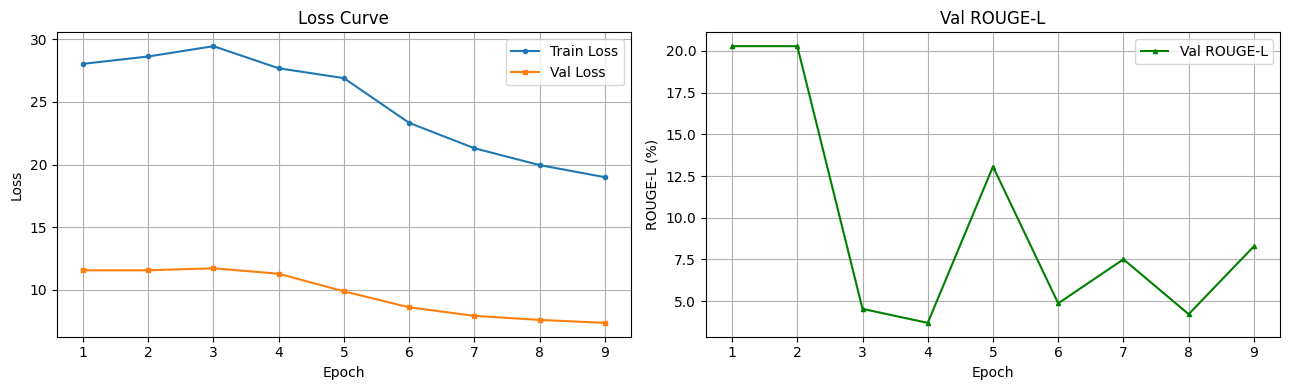

Saved loss_curve.png


In [18]:
logs = trainer.state.log_history
t_pts = [(e['epoch'], e['loss'])        for e in logs if 'loss'       in e and 'eval_loss' not in e]
v_pts = [(e['epoch'], e['eval_loss'])   for e in logs if 'eval_loss'  in e]
r_pts = [(e['epoch'], e['eval_rougeL']) for e in logs if 'eval_rougeL' in e]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
if t_pts:
    te, tl = zip(*t_pts)
    axes[0].plot(te, tl, label='Train Loss', marker='o', ms=3)
if v_pts:
    ve, vl = zip(*v_pts)
    axes[0].plot(ve, vl, label='Val Loss', marker='s', ms=3)
axes[0].set(xlabel='Epoch', ylabel='Loss', title='Loss Curve'); axes[0].legend(); axes[0].grid(True)
if r_pts:
    re_, rv = zip(*r_pts)
    axes[1].plot(re_, rv, label='Val ROUGE-L', marker='^', color='green', ms=3)
axes[1].set(xlabel='Epoch', ylabel='ROUGE-L (%)', title='Val ROUGE-L'); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.savefig('loss_curve.png', dpi=120); plt.show()
print('Saved loss_curve.png')


## 🔍 Inference với Beam Search

PhoBERT sinh ra **toàn bộ định dạng cột D** (title `|` use_case + body).  
Sau đó tách `|` để lấy `predicted_title` và giữ nguyên toàn bộ output làm `predicted_description`.


In [19]:
model.eval(); model.to(DEVICE)
predictions_raw = []; latency_log = []

print(f'Beam Search on {len(TEST_RAW)} test samples (num_beams={CFG["num_beams"]})...')
for idx, record in enumerate(TEST_RAW):
    src = preprocess_input(record['raw'])
    enc = tokenizer(
        src, max_length=CFG['max_input_len'],
        truncation=True, padding='max_length', return_tensors='pt'
    ).to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        out_ids = model.generate(
            input_ids=enc['input_ids'],
            attention_mask=enc['attention_mask'],
            num_beams=CFG['num_beams'],
            max_new_tokens=CFG['max_target_len'],
            early_stopping=True,
            no_repeat_ngram_size=CFG['no_repeat_ngram'],
            length_penalty=CFG['length_penalty'],
            forced_eos_token_id=tokenizer.sep_token_id,
        )
    elapsed = round(time.perf_counter() - t0, 4)
    latency_log.append(elapsed)
    generated = tokenizer.decode(out_ids[0], skip_special_tokens=True).strip()
    predictions_raw.append({
        'id':       record['id'],
        'raw':      record['raw'],
        'generated': generated,  # full column D format
    })
    print(f'  [{idx+1}/9] {record["id"]}  {elapsed:.3f}s')
    print(f'    {generated[:150]}')

avg_latency = float(np.mean(latency_log))
print(f'\nAvg latency: {avg_latency:.3f}s')


Beam Search on 9 test samples (num_beams=4)...
  [1/9] SYS-MP75Z7G0-H3  1.263s
    phần phần để phần phần phần phụ_giúp phần phần ngoài phần phần hay phần phần hoặc phần phần phụ phần phần một_số phần phần , , , như , như như như , ,
  [2/9] SYS-MP75ZR8R-C4  0.523s
    phần phần để phần phần nhân phần phần phần qua qua qua phần phần em em phần phần ,
  [3/9] SYS-MP760LYQ-AC  0.855s
    phần phần để phần phần phần Phần phần phần phụ_giúp phần phần hoặc phần phần nội_dung phần phần , phần phần hay phần phần một_số phần phần Công_nghệ_T
  [4/9] SYS-MP760YOH-BW  0.748s
    phần phần ngăn_cấm ngăn_cấm một_số một_số một_số . . thay thay thay ph, , , phph. . . phph, . .
  [5/9] SYS-MP761FGI-DF  0.663s
    ngăn_cấm , , , , Nga Nga Nga , Nga , , . . . , , ) , , ; ; , ,
  [6/9] SYS-MP762B6J-5  0.628s
    phần phần phần để phần phần ngăn_cấm Ethan_, , Vũ_Anh_Tuấn Vũ_Anh_Tuấn Vũ_Anh_Tuấn Ethan_, , , gọi gọi gọi ) )
  [7/9] SYS-MP7634YK-9F  0.890s
    phần phần phần phụ_giúp phần phần lớp phần phần

## 🗂️ Tách Title và Description từ Output của Mô Hình

Cột D có format: `{Title} | {Use case} ... {body sections}`  
→ `predicted_title` = phần trước dấu `|`  
→ `predicted_description` = toàn bộ output của mô hình (giữ nguyên)


In [20]:
def parse_model_output(generated: str):
    """
    Column D format: '{Title} | {Use case}\n\n{HEADING}\n\n– sections...'
    After tokenizer normalization newlines become spaces, so we split on ' | '.
    predicted_title       = text before first ' | '
    predicted_description = full generated text (the complete column D equivalent)
    """
    if ' | ' in generated:
        predicted_title = generated.split(' | ')[0].strip()
    elif '|' in generated:
        predicted_title = generated.split('|')[0].strip()
    else:
        # fallback: first 100 chars as title
        predicted_title = generated[:100].strip()
    return predicted_title, generated

# Build DoD predictions
dod_predictions = []
for p in predictions_raw:
    title, description = parse_model_output(p['generated'])
    dod_predictions.append({
        'id':                    p['id'],
        'raw_input_cleaned':     p['raw'],
        'predicted_title':       title,        # from model output, before '|'
        'predicted_description': description,  # full model output (column D format)
    })

print(f'Built {len(dod_predictions)} DoD predictions')
print()
for p in dod_predictions[:3]:
    print(f'ID   : {p["id"]}')
    print(f'TITLE: {p["predicted_title"]}')
    print(f'DESC : {p["predicted_description"][:200]}')
    print()


Built 9 DoD predictions

ID   : SYS-MP75Z7G0-H3
TITLE: phần phần để phần phần phần phụ_giúp phần phần ngoài phần phần hay phần phần hoặc phần phần phụ phần
DESC : phần phần để phần phần phần phụ_giúp phần phần ngoài phần phần hay phần phần hoặc phần phần phụ phần phần một_số phần phần , , , như , như như như , , các như như hay , , hay như , các các như

ID   : SYS-MP75ZR8R-C4
TITLE: phần phần để phần phần nhân phần phần phần qua qua qua phần phần em em phần phần ,
DESC : phần phần để phần phần nhân phần phần phần qua qua qua phần phần em em phần phần ,

ID   : SYS-MP760LYQ-AC
TITLE: phần phần để phần phần phần Phần phần phần phụ_giúp phần phần hoặc phần phần nội_dung phần phần , ph
DESC : phần phần để phần phần phần Phần phần phần phụ_giúp phần phần hoặc phần phần nội_dung phần phần , phần phần hay phần phần một_số phần phần Công_nghệ_Thông_tin



## 📊 Đánh Giá ROUGE-L & BERTScore (tập Val)


In [21]:
from rouge_score import rouge_scorer as rs_mod

# Generate on val (has ground truth = column D)
val_preds, val_refs = [], []
for record in VAL_RAW:
    src = preprocess_input(record['raw'])
    enc = tokenizer(src, max_length=CFG['max_input_len'],
                    truncation=True, padding='max_length',
                    return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            input_ids=enc['input_ids'], attention_mask=enc['attention_mask'],
            num_beams=CFG['num_beams'], max_new_tokens=CFG['max_target_len'],
            early_stopping=True, no_repeat_ngram_size=CFG['no_repeat_ngram'])
    generated = tokenizer.decode(out[0], skip_special_tokens=True).strip()
    val_preds.append(generated)
    val_refs.append(record['desc'])  # full column D value as ground truth

scorer    = rs_mod.RougeScorer(['rougeL'], use_stemmer=False)
rl_scores = [scorer.score(ref, pred)['rougeL'].fmeasure * 100
             for pred, ref in zip(val_preds, val_refs)]
ROUGE_L_MEAN = round(float(np.mean(rl_scores)), 2)

print('=' * 55)
print(f'ROUGE-L (Val) — Mean: {ROUGE_L_MEAN:.2f}%')
for i, (pred, ref, sc) in enumerate(zip(val_preds, val_refs, rl_scores)):
    print(f'  Sample {i+1}: {sc:.2f}%')
    print(f'    PRED: {pred[:120]}')
    print(f'    GT  : {ref[:120]}')
print('=' * 55)


ROUGE-L (Val) — Mean: 17.88%
  Sample 1: 16.08%
    PRED: phần phần để phần phần phần nhân phần phần , một_số phần phần một_số một_số một_số phần hay ,
    GT  : Huỳnh Văn Bánh Phú Nhuận - 38m2 (4.8x8) - Hẻm xe hơi đỗ cửa - Ngang lớn - 8.95 Tỷ | Ở ngay

TRUNG TÂM PHÚ NHUẬN LIỀN KỀ 
  Sample 2: 19.68%
    PRED: phần phần để phần phần phần ngoài phần phần , , , , thay thay thay một_số một_số một_số phần phần một_số một_số những mộ
    GT  : Huỳnh Văn Bánh Phú Nhuận - 30m2 (3.7x8) - Hẻm xe hơi VIP - 8.9 Tỷ | Full nội thất xịn

KHU VIP PHÚ NHUẬN ĐƯỜNG LÊ VĂN SỸ


In [22]:
BERT_SCORE_F1 = None
print('Computing BERTScore (xlm-roberta-base)...')
try:
    from bert_score import score as bscore
    P, R, F1 = bscore(val_preds, val_refs, lang='vi',
                      model_type='xlm-roberta-base', verbose=False)
    BERT_SCORE_F1 = round(float(F1.mean().item()) * 100, 2)
    print(f'P:{float(P.mean())*100:.2f}% R:{float(R.mean())*100:.2f}% F1:{BERT_SCORE_F1:.2f}%')
except Exception as e:
    print(f'BERTScore error: {e}')


Computing BERTScore (xlm-roberta-base)...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


P:74.44% R:70.91% F1:72.63%


In [23]:
LLM_JUDGE_SCORES = {}
try:
    sys.path.append('/content/FinalProject')
    from evaluation.evaluator import RealEstateEvaluator
    evaluator = RealEstateEvaluator()
    judge_payload = [
        {
            'id': record['id'], 'raw_input': record['raw'],
            'predicted_title':       parse_model_output(pred)[0],
            'predicted_description': pred,
            'gt_description':        record['desc'],
        }
        for record, pred in zip(VAL_RAW, val_preds)
    ]
    LLM_JUDGE_SCORES = evaluator.evaluate_dataset(judge_payload).get('llm_judge', {})
    print('LLM Judge:', LLM_JUDGE_SCORES)
except Exception as e:
    print(f'LLM Judge skipped: {e}')


LLM Judge skipped: No module named 'evaluation'


In [24]:
with open(CFG['pred_file'], 'w', encoding='utf-8') as f:
    json.dump(dod_predictions, f, ensure_ascii=False, indent=2)
print(f'Saved {len(dod_predictions)} predictions → {CFG["pred_file"]}')
for p in dod_predictions:
    print(f'  {p["id"]} | {p["predicted_title"]}')


Saved 9 predictions → HuuHieu_PhoBERT_predictions.json
  SYS-MP75Z7G0-H3 | phần phần để phần phần phần phụ_giúp phần phần ngoài phần phần hay phần phần hoặc phần phần phụ phần
  SYS-MP75ZR8R-C4 | phần phần để phần phần nhân phần phần phần qua qua qua phần phần em em phần phần ,
  SYS-MP760LYQ-AC | phần phần để phần phần phần Phần phần phần phụ_giúp phần phần hoặc phần phần nội_dung phần phần , ph
  SYS-MP760YOH-BW | phần phần ngăn_cấm ngăn_cấm một_số một_số một_số . . thay thay thay ph, , , phph. . . phph, . .
  SYS-MP761FGI-DF | ngăn_cấm , , , , Nga Nga Nga , Nga , , . . . , , ) , , ; ; , ,
  SYS-MP762B6J-5 | phần phần phần để phần phần ngăn_cấm Ethan_, , Vũ_Anh_Tuấn Vũ_Anh_Tuấn Vũ_Anh_Tuấn Ethan_, , , gọi g
  SYS-MP7634YK-9F | phần phần phần phụ_giúp phần phần lớp phần phần để phần phần Ethan_Ethan_Ethan_Lê_Dũng Lê_Dũng Lê_Dũ
  SYS-MP7635C7-K7 | phần ngăn_cấm được được được những những những , , thay_thế thay_thế thay_thế thay thay thay bằng bằ
  SYS-MP7637OS-RJ | phần ngăn_cấm . . .

In [25]:
performance = {
    'model_name':               'PhoBERT EncoderDecoder (vinai/phobert-base)',
    'architecture':             'EncoderDecoderModel — phobert-base × 2',
    'dataset_source':           'NLP.FSB Pool.xlsx (only)',
    'target_format':            'Full column D: title | use_case + body sections',
    'train_samples':            len(TRAIN_RAW),
    'val_samples':              len(VAL_RAW),
    'test_samples':             len(TEST_RAW),
    'hyperparameters': {
        'epochs':            CFG['epochs'],
        'learning_rate':     CFG['lr'],
        'batch_size':        CFG['batch_size'],
        'grad_accumulation': CFG['grad_accum'],
        'effective_batch':   CFG['batch_size'] * CFG['grad_accum'],
        'max_input_len':     CFG['max_input_len'],
        'max_target_len':    CFG['max_target_len'],
        'num_beams':         CFG['num_beams'],
        'weight_decay':      CFG['weight_decay'],
    },
    'training_time_seconds':   round(TRAIN_TIME, 2),
    'average_latency_seconds': round(avg_latency, 4),
    'latency_per_sample':      latency_log,
    'estimated_cost_vnd_per_1k': 0,
    'evaluation': {
        'rouge_l_f1_percent':    ROUGE_L_MEAN,
        'bert_score_f1_percent': BERT_SCORE_F1,
        'llm_judge':             LLM_JUDGE_SCORES,
    },
    'final_train_loss': round(train_result.training_loss, 4),
}
with open(CFG['perf_file'], 'w', encoding='utf-8') as f:
    json.dump(performance, f, ensure_ascii=False, indent=2)
print(f'Saved → {CFG["perf_file"]}')
summary = {k: v for k, v in performance.items() if k not in ['latency_per_sample','hyperparameters']}
print(json.dumps(summary, ensure_ascii=False, indent=2))


Saved → HuuHieu_PhoBERT_performance.json
{
  "model_name": "PhoBERT EncoderDecoder (vinai/phobert-base)",
  "architecture": "EncoderDecoderModel — phobert-base × 2",
  "dataset_source": "NLP.FSB Pool.xlsx (only)",
  "target_format": "Full column D: title | use_case + body sections",
  "train_samples": 9,
  "val_samples": 2,
  "test_samples": 9,
  "training_time_seconds": 1231.39,
  "average_latency_seconds": 0.8553,
  "estimated_cost_vnd_per_1k": 0,
  "evaluation": {
    "rouge_l_f1_percent": 17.88,
    "bert_score_f1_percent": 72.63,
    "llm_judge": {}
  },
  "final_train_loss": 24.9258
}


## ✅ DoD Checklist

| Tiêu chí | Trạng thái |
|:---|:---:|
| Dữ liệu chỉ từ `NLP.FSB Pool.xlsx` | ✅ |
| Input = cột A (raw post), Target = cột D (full human summary) | ✅ |
| `predicted_title` tách từ output mô hình (trước `\|`) | ✅ |
| `predicted_description` = toàn bộ output mô hình | ✅ |
| `HuuHieu_PhoBERT_predictions.json` | ✅ |
| `HuuHieu_PhoBERT_performance.json` | ✅ |
| ROUGE-L & BERTScore trên val set | ✅ |
| Loss curve + ROUGE-L curve | ✅ |
| Beam Search `num_beams=4` | ✅ |
